In [2]:
import numpy as np
import argparse
import random
import scipy.sparse as sp
from scipy.sparse.linalg import lobpcg
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score as acc
import torch
from torch_geometric.nn import MessagePassing, GCNConv, GATConv, SAGEConv,ChebConv,FAConv
from torch_geometric.nn import global_mean_pool

from torch_geometric.utils import add_self_loops, degree
from torch_geometric.utils import get_laplacian
import torch.nn as nn
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.data import Data,InMemoryDataset

from torch_scatter import scatter_add
from torch_sparse import SparseTensor, fill_diag, matmul, mul
from torch_sparse import sum as sparsesum

import matplotlib.pyplot as plt

from GNN import GNN

def high_dim_gaussian(mu, sigma):
    if mu.ndim > 1:
        d = len(mu)
        res = np.zeros(d)
        for i in range(d):
            res[i] = np.random.normal(mu[i], sigma[i])
    else:
        d = 1
        res = np.zeros(d)
        res = np.random.normal(mu, sigma)
    return res


def SBM(sizes, probs, mus, sigmas, feats_type='gaussian', selfloops=True):
    # c: class_number  d: dimension_number   n_i: number of class_i
    c = len(sizes)
    if mus.ndim > 1:
        d = mus.shape[1]
    else:
        d = 1
    n = sizes.sum()
    all_node_ids = [ids for ids in range(0, n)]
    Y = np.zeros(n, dtype='int')
    for i in range(c):
        class_i_ids = random.sample(all_node_ids, sizes[i])
        Y[class_i_ids] = i
        for item in class_i_ids:
            all_node_ids.remove(item)
    if selfloops:
        A = np.diag(np.ones(n, dtype='int'))
        E = [[i, i] for i in range(0, n)]
    else:
        A = np.zeros((n, n), dtype='int')
        E = []
    for i in range(n):
        for j in range(i + 1, n):
            prob_ = probs[Y[i]][Y[j]]
            rand_ = random.random()
            if rand_ <= prob_:
                A[i][j] = 1
                A[j][i] = 1
                E.append([i, j])
                E.append([j, i])
    X = np.zeros((n, d), dtype='float')
    E = np.array(E)
    for i in range(n):
        mu = mus[Y[i]]
        sigma = sigmas[Y[i]]
        X[i] = high_dim_gaussian(mu, sigma)

    return A, E, X, Y


def generate(p, q):
    A, E, X, Y = \
        SBM(sizes=np.array([50, 50]),
            probs=np.array([[p, q], [q, p]]),
            mus=np.array([[-0.5] * 2, [0.5] * 2]),
            sigmas=np.array([[1] * 2, [1] * 2]),
            selfloops=True)

    return A, E, X, Y


def compute_energy(v, L):
    """ compute the energy
        v: n * d
        L : n * n
        return tr(v.T * L * v)
    """

    # L = tonp(L)
    assert v.shape[0] == L.shape[0] == L.shape[1]
    E = torch.mm(torch.mm(v.T, L), v)
    E = torch.diag(E)
    E_total = E.sum()
    return E_total


def get_laplacian_mat(edge_index, edge_weight, num_node, normalization='sym'):
    """ return a laplacian (torch.sparse.tensor)"""
    edge_index, edge_weight = get_laplacian(edge_index, edge_weight,
                                            normalization=normalization)
    return torch.sparse.FloatTensor(edge_index, edge_weight, torch.Size([num_node, num_node]))


def get_laplacian_A(edge_index, edge_weight, num_node):
    """ return a laplacian (torch.sparse.tensor)"""
    edge_weight_L = -edge_weight
    for i in range(num_node):
        assert edge_index[:, i][0].item() == edge_index[:, i][1].item()
        edge_weight_L[i] += 1
    return torch.sparse.FloatTensor(edge_index, edge_weight_L, torch.Size([num_node, num_node]))


from torch_geometric.nn.conv import MessagePassing
class Energy_compute(MessagePassing):
  def __init__(self):
    super(Energy_compute, self).__init__()

  def compute_energy_(self,x,edge_index):
    energy = self.propagate(edge_index, x=x,energy = True)
    return torch.mean(energy,dim=0).item()
  def message(self, x_i,x_j,energy):
    # x_j has shape [E, out_channels]
    # Step 4: Normalize node features.
    #[E,1]*[E,channel]
    if energy:
        return (torch.linalg.norm(x_j-x_i, dim=1)**2).unsqueeze(dim=1)

  def forward(self,inter_step,edge_index):
    energy = []
    for i in inter_step:
      energy.append(self.compute_energy_(i,edge_index))
    return energy

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, num_layers,seed=114):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.sequence = [GCNConv(num_node_features, hidden_channels)]
        for i in range(num_layers-1):
          self.sequence.append(GCNConv(hidden_channels, hidden_channels))
        self.layers = nn.Sequential(*self.sequence)
        self.lin = Linear(hidden_channels, num_classes)


    def forward(self, x, edge_index):
        energies = []
        L_sp = get_laplacian_mat(edge_index,edge_weight = None, num_node =x.size(0), normalization="sym")
        L = L_sp.to_dense()
        energy = compute_energy(x,L)
        energies.append(x)
        for layer in self.layers[:-1]:
          x = layer(x,edge_index)
          energy = compute_energy(x,L)
          energies.append(x)
          x = x.relu()
        x = self.layers[-1](x,edge_index)
        energy = compute_energy(x,L)
        energies.append(x)

        # 2. Readout layer
        batch = torch.tensor([0]*x.size(0))
        x = global_mean_pool(x,batch)  # [1, hidden_channels]
        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x,energies



class GAT(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, num_layers,seed=114):
        super(GAT, self).__init__()
        torch.manual_seed(seed)
        self.sequence = [GATConv(num_node_features, hidden_channels)]
        for i in range(num_layers-1):
          self.sequence.append(GATConv(hidden_channels, hidden_channels))
        self.layers = nn.Sequential(*self.sequence)
        self.lin = Linear(hidden_channels, num_classes)


    def forward(self, x, edge_index):
        energies = []
        L_sp = get_laplacian_mat(edge_index,edge_weight = None,num_node =x.size(0), normalization="sym")
        L = L_sp.to_dense()
        energy = compute_energy(x,L)
        energies.append(x)
        for layer in self.layers[:-1]:
          x = layer(x,edge_index)
          energy = compute_energy(x,L)
          energies.append(x)
          x = x.relu()
        x = self.layers[-1](x,edge_index)
        energy = compute_energy(x,L)
        energies.append(x)

        # 2. Readout layer
        batch = torch.tensor([0]*x.size(0))
        x = global_mean_pool(x,batch)  # [1, hidden_channels]
        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x,energies



In [51]:
parser = argparse.ArgumentParser()
parser.add_argument('--use_cora_defaults', action='store_true',
                    help='Whether to run with best params for cora. Overrides the choice of dataset')
# data args
parser.add_argument('--dataset', type=str, default='Cora',
                    help='Cora, Citeseer, Pubmed, Computers, Photo, CoauthorCS, ogbn-arxiv')
parser.add_argument('--data_norm', type=str, default='gcn',
                    help='rw for random walk, gcn for symmetric gcn norm')
parser.add_argument('--self_loop_weight', type=float, default=1.0, help='Weight of self-loops.')
parser.add_argument('--use_labels', dest='use_labels', action='store_true', help='Also diffuse labels')
parser.add_argument('--geom_gcn_splits', dest='geom_gcn_splits', action='store_true',
                    help='use the 10 fixed splits from '
                        'https://arxiv.org/abs/2002.05287')
parser.add_argument('--num_splits', type=int, dest='num_splits', default=1,
                    help='the number of splits to repeat the results on')
parser.add_argument('--label_rate', type=float, default=0.5,
                    help='% of training labels to use when --use_labels is set.')
parser.add_argument('--planetoid_split', action='store_true',
                    help='use planetoid splits for Cora/Citeseer/Pubmed')
# GNN args
parser.add_argument('--hidden_dim', type=int, default=80, help='Hidden dimension.')
parser.add_argument('--fc_out', dest='fc_out', action='store_true',
                    help='Add a fully connected layer to the decoder.')
parser.add_argument('--input_dropout', type=float, default=0.5, help='Input dropout rate.')
parser.add_argument('--dropout', type=float, default=0.0, help='Dropout rate.')
parser.add_argument("--batch_norm", dest='batch_norm', action='store_true', help='search over reg params')
parser.add_argument('--optimizer', type=str, default='adam', help='One from sgd, rmsprop, adam, adagrad, adamax.')
parser.add_argument('--lr', type=float, default=0.001, help='Learning rate.')
parser.add_argument('--decay', type=float, default=5e-2, help='Weight decay for optimization')
parser.add_argument('--epoch', type=int, default=150, help='Number of training epochs per iteration.')
parser.add_argument('--alpha', type=float, default=1.0, help='Factor in front matrix A.')
parser.add_argument('--alpha_dim', type=str, default='sc', help='choose either scalar (sc) or vector (vc) alpha')
parser.add_argument('--damping_alpha', type=float, default=1.0, help='damping_coefficient')
parser.add_argument('--damping_gamma', type=float, default=0.76, help='damping_coefficient')
parser.add_argument('--alpha_activate', action='store_false',
                    help='apply activate function before multiplying by alpha')
parser.add_argument('--beta_dim', type=str, default='sc', help='choose either scalar (sc) or vector (vc) beta')
parser.add_argument('--block', type=str, default='constant', help='constant, mixed, attention, hard_attention')
parser.add_argument('--function', type=str, default='laplacian', help='laplacian, transformer, dorsey, GAT')
parser.add_argument('--use_mlp', dest='use_mlp', action='store_true',
                    help='Add a fully connected layer to the encoder.')
parser.add_argument('--add_source', dest='add_source', action='store_true',
                    help='If try get rid of alpha param and the beta*x0 source term')
parser.add_argument('--cgnn', dest='cgnn', action='store_true', help='Run the baseline CGNN model from ICML20')
parser.add_argument('--residual_connect', action='store_false',
                    help='double the length of the feature vector by appending zeros to stabilist ODE learning') 
# ODE args
parser.add_argument('--time', type=float, default=30, help='End time of ODE integrator.')
parser.add_argument('--augment', action='store_true',
                    help='double the length of the feature vector by appending zeros to stabilist ODE learning')
parser.add_argument('--second_order', action='store_true',
                    help='second order term in ODE')  
parser.add_argument('--allen_cahn', action='store_false',
                    help='modified allen_cahn term which may help to overcome oversmoothing problem')   
parser.add_argument('--method', type=str, default='dopri5',help="set the numerical solver: dopri5, euler, rk4, midpoint")
parser.add_argument('--step_size', type=float, default=0.1,
                    help='fixed step size when using fixed step solvers e.g. rk4')
parser.add_argument('--max_iters', type=float, default=100, help='maximum number of integration steps')
parser.add_argument("--adjoint_method", type=str, default="adaptive_heun",
                    help="set the numerical solver for the backward pass: dopri5, euler, rk4, midpoint")
parser.add_argument('--adjoint', dest='adjoint', action='store_true',
                    help='use the adjoint ODE method to reduce memory footprint')
parser.add_argument('--adjoint_step_size', type=float, default=1,
                    help='fixed step size when using fixed step adjoint solvers e.g. rk4')
parser.add_argument('--tol_scale', type=float, default=821.97, help='multiplier for atol and rtol')
parser.add_argument("--tol_scale_adjoint", type=float, default=1.0,
                    help="multiplier for adjoint_atol and adjoint_rtol")
parser.add_argument('--ode_blocks', type=int, default=1, help='number of ode blocks to run')
parser.add_argument("--max_nfe", type=int, default=10000,
                    help="Maximum number of function evaluations in an epoch. Stiff ODEs will hang if not set.")
parser.add_argument("--no_early", action="store_false",
                    help="Whether or not to use early stopping of the ODE integrator when testing.")
parser.add_argument('--earlystopxT', type=float, default=3, help='multiplier for T used to evaluate best model')
parser.add_argument("--max_test_steps", type=int, default=100,
                    help="Maximum number steps for the dopri5Early test integrator. "
                        "used if getting OOM errors at test time")

# Attention args
parser.add_argument('--leaky_relu_slope', type=float, default=0.2,
                    help='slope of the negative part of the leaky relu used in attention')
parser.add_argument('--attention_dropout', type=float, default=0., help='dropout of attention weights')
parser.add_argument('--heads', type=int, default=4, help='number of attention heads')
parser.add_argument('--attention_norm_idx', type=int, default=0, help='0 = normalise rows, 1 = normalise cols')
parser.add_argument('--attention_dim', type=int, default=64,
                    help='the size to project x to before calculating att scores')
parser.add_argument('--mix_features', dest='mix_features', action='store_true',
                    help='apply a feature transformation xW to the ODE')
parser.add_argument('--reweight_attention', dest='reweight_attention', action='store_true',
                    help="multiply attention scores by edge weights before softmax")
parser.add_argument('--attention_type', type=str, default="scaled_dot",
                    help="scaled_dot,cosine_sim,pearson, exp_kernel")
parser.add_argument('--square_plus', action='store_true', help='replace softmax with square plus')

# regularisation args
parser.add_argument('--jacobian_norm2', type=float, default=None, help="int_t ||df/dx||_F^2")
parser.add_argument('--total_deriv', type=float, default=None, help="int_t ||df/dt||^2")

parser.add_argument('--kinetic_energy', type=float, default=None, help="int_t ||f||_2^2")
parser.add_argument('--directional_penalty', type=float, default=None, help="int_t ||(df/dx)^T f||^2")

# rewiring args
parser.add_argument("--not_lcc", action="store_false", help="don't use the largest connected component")
parser.add_argument('--rewiring', type=str, default=None, help="two_hop, gdc")
parser.add_argument('--gdc_method', type=str, default='ppr', help="ppr, heat, coeff")
parser.add_argument('--gdc_sparsification', type=str, default='topk', help="threshold, topk")
parser.add_argument('--gdc_k', type=int, default=64, help="number of neighbours to sparsify to when using topk")
parser.add_argument('--gdc_threshold', type=float, default=0.0001,
                    help="obove this edge weight, keep edges when using threshold")
parser.add_argument('--gdc_avg_degree', type=int, default=64,
                    help="if gdc_threshold is not given can be calculated by specifying avg degree")
parser.add_argument('--ppr_alpha', type=float, default=0.05, help="teleport probability")
parser.add_argument('--heat_time', type=float, default=3., help="time to run gdc heat kernal diffusion for")
parser.add_argument('--att_samp_pct', type=float, default=1,
                    help="float in [0,1). The percentage of edges to retain based on attention scores")
parser.add_argument('--use_flux', dest='use_flux', action='store_true',
                    help='incorporate the feature grad in attention based edge dropout')
parser.add_argument("--exact", action="store_true",
                    help="for small datasets can do exact diffusion. If dataset is too big for matrix inversion then you can't")
parser.add_argument('--M_nodes', type=int, default=64, help="new number of nodes to add")
parser.add_argument('--new_edges', type=str, default="random", help="random, random_walk, k_hop")
parser.add_argument('--sparsify', type=str, default="S_hat", help="S_hat, recalc_att")
parser.add_argument('--threshold_type', type=str, default="topk_adj", help="topk_adj, addD_rvR")
parser.add_argument('--rw_addD', type=float, default=0.02, help="percentage of new edges to add")
parser.add_argument('--rw_rmvR', type=float, default=0.02, help="percentage of edges to remove")
parser.add_argument('--rewire_KNN', action='store_true', help='perform KNN rewiring every few epochs')
parser.add_argument('--rewire_KNN_T', type=str, default="T0", help="T0, TN")
parser.add_argument('--rewire_KNN_epoch', type=int, default=5, help="frequency of epochs to rewire")
parser.add_argument('--rewire_KNN_k', type=int, default=64, help="target degree for KNN rewire")
parser.add_argument('--rewire_KNN_sym', action='store_true', help='make KNN symmetric')
parser.add_argument('--KNN_online', action='store_true', help='perform rewiring online')
parser.add_argument('--KNN_online_reps', type=int, default=4, help="how many online KNN its")
parser.add_argument('--KNN_space', type=str, default="pos_distance", help="Z,P,QKZ,QKp")

#particle argument
parser.add_argument('--particle_beta', type=str, default="single", help="data_type of beta in particle function,single or multi ")  
parser.add_argument('--function_type', type=str, default="duffision", help="function type, duffision or particle")  

# beltrami args
parser.add_argument('--beltrami', action='store_true', help='perform diffusion beltrami style')
parser.add_argument('--fa_layer', action='store_true', help='add a bottleneck paper style layer with more edges')
parser.add_argument('--pos_enc_type', type=str, default="DW64",
                    help='positional encoder either GDC, DW64, DW128, DW256')
parser.add_argument('--pos_enc_orientation', type=str, default="row", help="row, col")
parser.add_argument('--feat_hidden_dim', type=int, default=64, help="dimension of features in beltrami")
parser.add_argument('--pos_enc_hidden_dim', type=int, default=32, help="dimension of position in beltrami")
parser.add_argument('--edge_sampling', action='store_true', help='perform edge sampling rewiring')
parser.add_argument('--edge_sampling_T', type=str, default="T0", help="T0, TN")
parser.add_argument('--edge_sampling_epoch', type=int, default=5, help="frequency of epochs to rewire")
parser.add_argument('--edge_sampling_add', type=float, default=0.64, help="percentage of new edges to add")
parser.add_argument('--edge_sampling_add_type', type=str, default="importance",
                    help="random, ,anchored, importance, degree")
parser.add_argument('--edge_sampling_rmv', type=float, default=0.32, help="percentage of edges to remove")
parser.add_argument('--edge_sampling_sym', action='store_true', help='make KNN symmetric')
parser.add_argument('--edge_sampling_online', action='store_true', help='perform rewiring online')
parser.add_argument('--edge_sampling_online_reps', type=int, default=4, help="how many online KNN its")
parser.add_argument('--edge_sampling_space', type=str, default="attention",
                    help="attention,pos_distance, z_distance, pos_distance_QK, z_distance_QK")
parser.add_argument('--symmetric_attention', action='store_true',
                    help='maks the attention symmetric for rewring in QK space')

parser.add_argument('--fa_layer_edge_sampling_rmv', type=float, default=0.8, help="percentage of edges to remove")
parser.add_argument('--gpu', type=int, default=0, help="GPU to run on (default 0)")
parser.add_argument('--pos_enc_csv', action='store_true', help="Generate pos encoding as a sparse CSV")

parser.add_argument('--pos_dist_quantile', type=float, default=0.001, help="percentage of N**2 edges to keep")
parser.add_argument('--init_alpha', type=float, default=1.0, help="init value of coefficient of diffusion term")
parser.add_argument('--init_beta', type=float, default=1.0, help="init value of coefficient of diffusion term")  
parser.add_argument('--init_root', type=float, default=0.5, help="init value of root of allen cahn")
parser.add_argument('--multi_layer', action='store_true', help="init value of coefficient of diffusion term")    

args = parser.parse_args([])
opt = vars(args)


mp_compute_energy = Energy_compute()
# generate Graph data
A, E, X, Y = generate(p=0.9, q=0.1)
E = torch.tensor(E, dtype=torch.long)
X = torch.tensor(X, dtype=torch.float)
Y = torch.tensor(Y, dtype=torch.float)
data = Data(x=X, edge_index=E.t().contiguous(),y = Y)
torch.save(data,'paper_plot/new_random_graph.pt')
class MyOwnDataset(InMemoryDataset):
    def __init__(self, data, num_classes,num_features,num_nodes):
        super().__init__(data, num_classes,num_features,num_nodes)
        self.data =data
        
dataset = MyOwnDataset(data,2,2,100)
dic = {}
#GCN
gcn = GCN(num_node_features=2, hidden_channels=4, num_classes=2, num_layers=50)
out,interstep = gcn(data.x, data.edge_index)

e_GCN = mp_compute_energy(interstep,data.edge_index)
dic['GCN'] = e_GCN
torch.save(interstep,'paper_plot/new_GCN_inter.pt')
#GAT
gat = GAT(num_node_features=2, hidden_channels=4, num_classes=2, num_layers=50)
out,interstep = gat(data.x, data.edge_index)
e_GAT = mp_compute_energy(interstep,data.edge_index)
dic['GAT'] = e_GAT
torch.save(interstep,'paper_plot/new_gat_inter.pt')    
# #GRAND
# opt['hidden_dim'] = 2
# opt['allen_cahn'] = False
# opt['alpha_activate'] = False
# opt['method'] = 'midpoint'
# opt['step_size'] = 0.5
# ['no_alpha_sigmoid'] = True
# GRAND = GNN(opt,dataset,device = torch.device('cpu'))
# out = GRAND(data.x)
# interstep = GRAND.odeblock.odefunc.inter_step
# energy = mp_compute_energy(interstep,data.edge_index)
# dic['GRAND'] = energy
# torch.save(interstep,'paper_plot/new_GRAND_inter_1.pt')
# #ACMP
# opt['method'] = 'dopri5'
# for root in [0.1,0.3,0.5,0.7,0.9,1.0]:
#     opt['init_root'] = root
#     opt['allen_cahn'] = True
#     opt['alpha_activate'] = False
#     opt['alpha_activate_type'] = 'relu'
#     ACMP = GNN(opt,dataset,device = torch.device('cpu'))
#     out = ACMP(data.x)
#     interstep = ACMP.odeblock.odefunc.inter_step
#     energy = mp_compute_energy(interstep,data.edge_index)
#     dic['ACMP'+str(root)] = energy
#     torch.save(interstep,'paper_plot/new_ACMP'+str(root)+'_inter_1.pt')
# #ACMP+GAT
# for root in [0.1,0.3,0.5,0.7,0.9,1.0]:
#     opt['init_root'] = root
#     opt['allen_cahn'] = True
#     opt['alpha_activate'] = False
#     opt['block'] = 'attention'
#     ACMP = GNN(opt,dataset,device = torch.device('cpu'))
#     out = ACMP(data.x)
#     interstep = ACMP.odeblock.odefunc.inter_step
#     energy = mp_compute_energy(interstep,data.edge_index)
#     dic['ACMP_GAT'+str(root)] = energy
#     torch.save(interstep,'paper_plot/new_ACMP_GAT'+str(root)+'_inter_1.pt')
    
np.save('paper_plot/new_random_graph_energy.npy',dic)

In [52]:
#GRAND
opt['hidden_dim'] = 2
opt['allen_cahn'] = False
opt['alpha_activate'] = False
opt['method'] = 'midpoint'
opt['step_size'] = 0.5
opt['no_alpha_sigmoid'] = False
opt['add_force'] = False
GRAND = GNN(opt,dataset,device = torch.device('cpu'))
out = GRAND(data.x)
e_GRAND = GRAND.compute_enegry_evolution(data.edge_index, torch.linspace(0, opt['time'], steps=50))


In [53]:
#GRAND
opt['hidden_dim'] = 2
opt['allen_cahn'] = False
opt['alpha_activate'] = False
opt['method'] = 'midpoint'
opt['step_size'] = 0.5
opt['no_alpha_sigmoid'] = False
opt['add_force'] = False
opt['data_norm'] = 'ufg'

opt['channel_mix'] = True
opt['init_scale_1'] = 0.3
opt['init_scale_2'] = 0.1
opt['init_scale_3'] = 0.03
FMP = GNN(opt,dataset,device = torch.device('cpu'))
out = FMP(data.x)
# interstep = GRAND.odeblock.odefunc.inter_step
# energy = mp_compute_energy(interstep,data.edge_index)

In [54]:
e_FMP = FMP.compute_enegry_evolution(data.edge_index, torch.linspace(0, opt['time'], steps=50))

In [55]:
import seaborn as sns
sns.set()

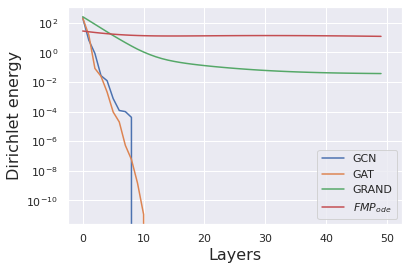

In [65]:
plt.figure()
plt.semilogy(e_GCN, label='GCN')
plt.semilogy(e_GAT, label='GAT')
plt.semilogy(e_GRAND, label='GRAND')
plt.semilogy(e_FMP, label='$FMP_{ode}$')
plt.xlabel('Layers', fontsize=16)
plt.ylabel('Dirichlet energy', fontsize=16)
plt.legend()
plt.savefig('paper_plot/dirichlet.png',dpi = 800, bbox_inches = "tight")
plt.show()

In [11]:
len(dic['GAT'])

51